# Modelling pipeline (grading-ready)

**Research question:** Are negative sentiment signals stronger predictors of market reactions than positive sentiment signals?

This notebook extends the project’s modelling stage to:

- Model **CAR_01**, **CAR_03** (preferred; else CAR_05 fallback), and **volatility_change**.
- Fit a consistent set of **OLS (statsmodels)** specifications for each outcome.
- Use **heteroskedasticity-robust standard errors (HC3)** for primary inference.
- Run a formal **asymmetry (Wald/F) test** of \(H_0: \beta_{neg} - \beta_{pos} = 0\) for each model containing a neg/pos sentiment pair.
- Use a deterministic **time split** (preferred: train 2016–2018, test 2019–2020) with a deterministic **fallback** if either split has < 50 observations after outcome-specific filtering.

**Inputs (generated earlier in the pipeline):**

- `../data/processed/event_study_dataset.csv`
- `../data/processed/lexicon_sentiment_features.csv`
- `../data/processed/finbert_sentiment_features.csv`

**Outputs (tables/plots in-notebook):**

- Per-outcome `model_performance_<outcome>` tables
- One combined performance table across outcomes
- `asymmetry_results` table with deterministic interpretation

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from pathlib import Path
from dataclasses import dataclass

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Resolve paths robustly regardless of Jupyter's working directory.
# We find the repo root by walking up until we see requirements.txt + data/
_cwd = Path.cwd().resolve()

REPO_ROOT = None
for _p in [_cwd, *_cwd.parents]:
    if (_p / "requirements.txt").is_file() and (_p / "data").is_dir():
        REPO_ROOT = _p
        break

if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from cwd={_cwd}")

DATA_DIR = REPO_ROOT / "data" / "processed"

EVENT_PATH = DATA_DIR / "event_study_dataset.csv"
LEX_PATH = DATA_DIR / "lexicon_sentiment_features.csv"
FIN_PATH = DATA_DIR / "finbert_sentiment_features.csv"

assert EVENT_PATH.is_file(), f"Missing: {EVENT_PATH}"
assert LEX_PATH.is_file(), f"Missing: {LEX_PATH}"
assert FIN_PATH.is_file(), f"Missing: {FIN_PATH}"

## Load data

We build a unified modelling dataset by merging:

- event outcomes and controls (`event_study_dataset.csv`)
- lexicon sentiment features (`lexicon_sentiment_features.csv`)
- FinBERT sentiment features (`finbert_sentiment_features.csv`)

In [2]:
events = pd.read_csv(EVENT_PATH)
lex = pd.read_csv(LEX_PATH)
fin = pd.read_csv(FIN_PATH)

merge_key = ["ticker", "file_name", "event_trading_day_final"]

print("Rows in raw event_study_dataset:", len(events))
print("Rows in lexicon_sentiment_features:", len(lex))
print("Rows in finbert_sentiment_features:", len(fin))

# Ensure types
for df in (events, lex, fin):
    if "event_trading_day_final" in df.columns:
        df["event_trading_day_final"] = pd.to_datetime(df["event_trading_day_final"], errors="coerce")

# Merge into unified dataset
_df = events.merge(lex, on=merge_key, how="inner").merge(fin, on=merge_key, how="inner")

# Derived controls
if "total_tokens" in _df.columns:
    _df["log_tokens"] = np.log(_df["total_tokens"].clip(lower=1))

_df["year"] = _df["year"].astype(int)

print("Rows after inner-merge (usable for sentiment models):", len(_df))
df = _df.copy()

display(df.head(3))

Rows in raw event_study_dataset: 188
Rows in lexicon_sentiment_features: 188
Rows in finbert_sentiment_features: 188
Rows after inner-merge (usable for sentiment models): 188


,ticker,file_name,year,quarter_label,call_datetime_et,after_market_close_et,event_trading_day_final,CAR_01,CAR_03,pre_volatility,post_volatility,volatility_change,file_path,call_date_from_filename,call_datetime_header_raw,call_datetime_parsed,call_datetime_gmt,call_time_gmt,call_time_et,error,total_tokens,neg_count_lm,pos_count_lm,neg_rate_lm,pos_rate_lm,finbert_pos_mean,finbert_neg_mean,finbert_neu_mean,log_tokens
0,AAPL,2016-Jan-26-AAPL.txt,2016,Q1,2016-01-26T17:00:00-05:00,True,2016-01-27,-0.043240,-0.045063,0.024005,0.018419,-0.005586,data/raw/earnings-call-transcripts/Transcripts...,2016-01-26,"JANUARY 26, 2016 / 10:00PM GMT",2016-01-26T22:00:00+00:00,2016-01-26T22:00:00+00:00,22:00:00,17:00:00,NaN,7965,14,60,0.001758,0.007533,0.164228,0.041350,0.656861,8.982812
1,AAPL,2016-Apr-26-AAPL.txt,2016,Q2,2016-04-26T17:00:00-04:00,True,2016-04-27,-0.074182,-0.089002,0.010551,0.012455,0.001904,data/raw/earnings-call-transcripts/Transcripts...,2016-04-26,"APRIL 26, 2016 / 9:00PM GMT",2016-04-26T21:00:00+00:00,2016-04-26T21:00:00+00:00,21:00:00,17:00:00,NaN,9209,18,39,0.001955,0.004235,0.234019,0.092476,0.503108,9.127937
2,AAPL,2016-Jul-26-AAPL.txt,2016,Q3,2016-07-26T17:00:00-04:00,True,2016-07-27,0.071901,0.084408,0.009706,0.010494,0.000788,data/raw/earnings-call-transcripts/Transcripts...,2016-07-26,"JULY 26, 2016 / 9:00PM GMT",2016-07-26T21:00:00+00:00,2016-07-26T21:00:00+00:00,21:00:00,17:00:00,NaN,7400,4,42,0.000541,0.005676,0.128360,0.041086,0.687425,8.909235


## Check variables and sample sizes

This section:

- detects outcome columns (CAR_01 + longer-window CAR + volatility_change)
- defines sentiment feature pairs (lexicon vs FinBERT)
- defines controls (pre_volatility + log_tokens if available)
- prints missingness and event counts by year

In [3]:
# ---- Outcome selection rule (deterministic) ----
outcome_candidates = ["CAR_01", "CAR_03", "CAR_05", "volatility_change"]
present_outcomes = {c: (c in df.columns) for c in outcome_candidates}

long_car = None
if present_outcomes.get("CAR_03", False):
    long_car = "CAR_03"
elif present_outcomes.get("CAR_05", False):
    long_car = "CAR_05"
else:
    print("[WARNING] No CAR_03 or CAR_05 column found; skipping longer-window CAR.")

outcomes_to_model = ["CAR_01"]
if long_car is not None:
    outcomes_to_model.append(long_car)
outcomes_to_model.append("volatility_change")

availability = pd.DataFrame(
    {
        "outcome": outcome_candidates,
        "present": [present_outcomes[c] for c in outcome_candidates],
        "will_model": [c in outcomes_to_model for c in outcome_candidates],
    }
)
print("Outcome availability and modelling choice:")
display(availability)

# ---- Sentiment feature detection (explicit, then verify presence) ----
lex_pair = ("neg_rate_lm", "pos_rate_lm")
fin_pair = ("finbert_neg_mean", "finbert_pos_mean")

for col in (*lex_pair, *fin_pair):
    assert col in df.columns, f"Missing required sentiment column: {col}"

print("Lexicon sentiment columns:", list(lex_pair))
print("FinBERT sentiment columns:", list(fin_pair))

# ---- Controls (required where present) ----
controls = []
for c in ["pre_volatility", "log_tokens"]:
    if c in df.columns:
        controls.append(c)

print("Selected control columns:", controls)

# Year/quarter indicators (kept as categorical dummies)
cat_controls = []
for c in ["year", "quarter_label"]:
    if c in df.columns:
        cat_controls.append(c)

print("Selected categorical controls:", cat_controls)

# ---- Basic dataset diagnostics ----
print("\nEvent counts by year (after inner merge):")
display(df["year"].value_counts().sort_index().rename_axis("year").to_frame("n_events"))

key_predictors = list(lex_pair) + list(fin_pair) + controls
missingness = df[[*outcomes_to_model, *key_predictors]].isna().mean().sort_values(ascending=False)
print("\nMissingness rate (outcomes + key predictors):")
display(missingness.to_frame("missing_rate"))

Outcome availability and modelling choice:


,outcome,present,will_model
0,CAR_01,True,True
1,CAR_03,True,True
2,CAR_05,False,False
3,volatility_change,True,True


Lexicon sentiment columns: ['neg_rate_lm', 'pos_rate_lm']
FinBERT sentiment columns: ['finbert_neg_mean', 'finbert_pos_mean']
Selected control columns: ['pre_volatility', 'log_tokens']
Selected categorical controls: ['year', 'quarter_label']

Event counts by year (after inner merge):


,n_events
year,
2016,40
2017,40
2018,39
2019,40
2020,29



Missingness rate (outcomes + key predictors):


,missing_rate
CAR_01,0.0
CAR_03,0.0
volatility_change,0.0
neg_rate_lm,0.0
pos_rate_lm,0.0
finbert_neg_mean,0.0
finbert_pos_mean,0.0
pre_volatility,0.0
log_tokens,0.0


## Define train/test split

**Preferred (deterministic):**

- Train years: 2016–2018
- Test years: 2019–2020

**Fallback rule:** After filtering to the required variables for a given outcome, if train or test has **< 50** observations, we fall back to a time split where the **last 20% of years** (or last 20% of dates) is used as test.

For grading clarity, we print the chosen split and final sizes per outcome.

In [4]:
@dataclass
class SplitInfo:
    split_type: str
    train_mask: pd.Series
    test_mask: pd.Series
    description: str


def preferred_year_split(df_: pd.DataFrame) -> SplitInfo:
    train_mask = df_["year"].between(2016, 2018)
    test_mask = df_["year"].between(2019, 2020)
    desc = "Preferred year split: train=2016–2018, test=2019–2020"
    return SplitInfo("preferred_year", train_mask, test_mask, desc)


def fallback_time_split(df_: pd.DataFrame) -> SplitInfo:
    # Prefer splitting by years; if not feasible, split by event date.
    if "year" in df_.columns and df_["year"].notna().all():
        years = sorted(df_["year"].unique().tolist())
        n_years = len(years)
        n_test_years = max(1, int(np.ceil(0.2 * n_years)))
        test_years = set(years[-n_test_years:])
        train_mask = ~df_["year"].isin(test_years)
        test_mask = df_["year"].isin(test_years)
        desc = f"Fallback split by year: test_years={sorted(test_years)} (last {n_test_years} / {n_years} years)"
        return SplitInfo("fallback_year", train_mask, test_mask, desc)

    # Date-based fallback
    if "event_trading_day_final" not in df_.columns:
        raise ValueError("No 'year' and no 'event_trading_day_final' available for fallback split")

    dates = pd.to_datetime(df_["event_trading_day_final"], errors="coerce")
    if dates.isna().any():
        raise ValueError("event_trading_day_final has missing/invalid values; cannot do date-based fallback split")

    cutoff = dates.quantile(0.8)
    train_mask = dates < cutoff
    test_mask = dates >= cutoff
    desc = f"Fallback split by date: cutoff={cutoff.date()} (last 20% of dates in test)"
    return SplitInfo("fallback_date", train_mask, test_mask, desc)


def choose_split(df_filtered: pd.DataFrame, min_n: int = 50) -> SplitInfo:
    # Try preferred split first
    pref = preferred_year_split(df_filtered)
    n_train = int(pref.train_mask.sum())
    n_test = int(pref.test_mask.sum())

    if n_train >= min_n and n_test >= min_n:
        return pref

    fb = fallback_time_split(df_filtered)
    return fb

## Fit models (OLS with HC3 robust SE)

For each outcome we estimate:

- **Null**: intercept only
- **Baseline controls**: controls only
- **Lexicon sentiment**: `neg_rate_lm`, `pos_rate_lm`
- **FinBERT sentiment**: `finbert_neg_mean`, `finbert_pos_mean`
- **Full (lexicon + controls)**
- **Full (FinBERT + controls)**
- **Optional combined**: lexicon + FinBERT + controls (only if sample size adequate)

All models are estimated with `statsmodels` OLS, and inference uses **HC3** robust covariance.

In [5]:
def rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def r2_out_of_sample(y_true: pd.Series, y_pred: pd.Series) -> float:
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    if ss_tot == 0:
        return float("nan")
    return 1.0 - ss_res / ss_tot


def build_design_matrices(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    add_const: bool = True,
):
    # Numeric predictors
    X_train = train_df[numeric_cols].copy() if numeric_cols else pd.DataFrame(index=train_df.index)
    X_test = test_df[numeric_cols].copy() if numeric_cols else pd.DataFrame(index=test_df.index)

    # One-hot encode categoricals using train categories only (prevents leakage)
    for c in categorical_cols:
        d_train = pd.get_dummies(train_df[c].astype("category"), prefix=c, drop_first=True)
        d_test = pd.get_dummies(test_df[c].astype("category"), prefix=c, drop_first=True)
        # Align columns
        d_test = d_test.reindex(columns=d_train.columns, fill_value=0)
        X_train = pd.concat([X_train, d_train], axis=1)
        X_test = pd.concat([X_test, d_test], axis=1)

    if add_const:
        X_train = sm.add_constant(X_train, has_constant="add")
        X_test = sm.add_constant(X_test, has_constant="add")

    # Coerce any object/bool columns to numeric (fail fast if something is truly non-numeric)
    X_train = X_train.apply(pd.to_numeric, errors="coerce")
    X_test = X_test.apply(pd.to_numeric, errors="coerce")

    if X_train.isna().any().any():
        bad_cols = X_train.columns[X_train.isna().any()].tolist()
        raise ValueError(f"Non-numeric values produced NaNs in X_train columns: {bad_cols}")
    if X_test.isna().any().any():
        bad_cols = X_test.columns[X_test.isna().any()].tolist()
        raise ValueError(f"Non-numeric values produced NaNs in X_test columns: {bad_cols}")

    return X_train, X_test


def fit_ols_hc3(y_train: pd.Series, X_train: pd.DataFrame):
    # Statsmodels can error if pandas objects carry an `object` dtype.
    # Force clean float numpy arrays for endog/exog while keeping column names for interpretation.
    y_arr = pd.Series(y_train).astype(float).to_numpy()
    X_arr = pd.DataFrame(X_train).astype(float).to_numpy()

    base_res = sm.OLS(y_arr, X_arr).fit()
    robust_res = base_res.get_robustcov_results(cov_type="HC3")
    return base_res, robust_res


def run_model(
    df_outcome: pd.DataFrame,
    outcome: str,
    numeric_predictors: list[str],
    categorical_predictors: list[str],
    model_name: str,
    min_n_for_combined: int = 100,
):
    # Filter to complete cases for just the variables needed
    needed_cols = [outcome] + numeric_predictors + categorical_predictors
    d = df_outcome.dropna(subset=needed_cols).copy()

    split = choose_split(d, min_n=50)
    train_df = d[split.train_mask].copy()
    test_df = d[split.test_mask].copy()

    print(f"\n[{outcome}] {model_name}")
    print("Split:", split.description)
    print(f"N train={len(train_df)}, N test={len(test_df)}")

    y_train = train_df[outcome].astype(float)
    y_test = test_df[outcome].astype(float)

    X_train, X_test = build_design_matrices(train_df, test_df, numeric_predictors, categorical_predictors, add_const=True)

    base_res, robust_res = fit_ols_hc3(y_train, X_train)

    # Performance
    yhat_train = base_res.predict(X_train)
    yhat_test = base_res.predict(X_test)

    train_r2 = float(base_res.rsquared)
    test_r2 = r2_out_of_sample(y_test, yhat_test)
    test_rmse = rmse(y_test, yhat_test)

    return {
        "outcome": outcome,
        "model": model_name,
        "predictors": ",".join([*numeric_predictors, *[f"C({c})" for c in categorical_predictors]]),
        "n_train": len(train_df),
        "n_test": len(test_df),
        "train_r2": train_r2,
        "test_r2": test_r2,
        "test_rmse": test_rmse,
        "base_results": base_res,
        "robust_results": robust_res,
        "X_train_cols": list(X_train.columns),
    }

In [6]:
# Model specifications (numeric predictors only; categorical dummies are added consistently as controls)

# Controls used in baseline and full models
controls_num = controls.copy()
controls_cat = cat_controls.copy()

specs = []
for outcome in outcomes_to_model:
    # Null
    specs.append((outcome, "null", [], []))

    # Baseline controls
    specs.append((outcome, "baseline_controls", controls_num, controls_cat))

    # Sentiment-only
    specs.append((outcome, "lexicon_sentiment", [*lex_pair], []))
    specs.append((outcome, "finbert_sentiment", [*fin_pair], []))

    # Full models
    specs.append((outcome, "full_lexicon_plus_controls", [*lex_pair, *controls_num], controls_cat))
    specs.append((outcome, "full_finbert_plus_controls", [*fin_pair, *controls_num], controls_cat))

print("Planned model specs per outcome:")
display(pd.DataFrame(specs, columns=["outcome", "model", "numeric_predictors", "categorical_predictors"]))

Planned model specs per outcome:


,outcome,model,numeric_predictors,categorical_predictors
0,CAR_01,null,[],[]
1,CAR_01,baseline_controls,"[pre_volatility, log_tokens]","[year, quarter_label]"
2,CAR_01,lexicon_sentiment,"[neg_rate_lm, pos_rate_lm]",[]
3,CAR_01,finbert_sentiment,"[finbert_neg_mean, finbert_pos_mean]",[]
4,CAR_01,full_lexicon_plus_controls,"[neg_rate_lm, pos_rate_lm, pre_volatility, log...","[year, quarter_label]"
5,CAR_01,full_finbert_plus_controls,"[finbert_neg_mean, finbert_pos_mean, pre_volat...","[year, quarter_label]"
6,CAR_03,null,[],[]
7,CAR_03,baseline_controls,"[pre_volatility, log_tokens]","[year, quarter_label]"
8,CAR_03,lexicon_sentiment,"[neg_rate_lm, pos_rate_lm]",[]
9,CAR_03,finbert_sentiment,"[finbert_neg_mean, finbert_pos_mean]",[]


In [7]:
results = []

for outcome, model_name, num_pred, cat_pred in specs:
    out = run_model(df, outcome, num_pred, cat_pred, model_name)
    results.append(out)

# Optional combined model (lexicon + FinBERT + controls) if feasible
for outcome in outcomes_to_model:
    combined_num = [*lex_pair, *fin_pair, *controls_num]
    combined_cat = controls_cat

    needed_cols = [outcome] + combined_num + combined_cat
    d = df.dropna(subset=needed_cols).copy()
    split = choose_split(d, min_n=50)
    n_train = int(split.train_mask.sum())

    # simple adequacy rule: require >= 100 training obs and at least 10 obs per parameter
    # (parameter count = const + predictors + dummies)
    if n_train < 100:
        print(f"\n[{outcome}] Skipping combined model: training N too small (N={n_train} < 100)")
        continue

    out = run_model(df, outcome, combined_num, combined_cat, "combined_lexicon_finbert_controls")
    results.append(out)

perf_rows = [
    {k: r[k] for k in ["outcome", "model", "predictors", "n_train", "n_test", "train_r2", "test_r2", "test_rmse"]}
    for r in results
]

performance_all = pd.DataFrame(perf_rows).sort_values(["outcome", "model"]).reset_index(drop=True)

print("\nCombined performance table across outcomes:")
display(performance_all)


[CAR_01] null
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_01] baseline_controls
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_01] lexicon_sentiment
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_01] finbert_sentiment
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_01] full_lexicon_plus_controls
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_01] full_finbert_plus_controls
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_03] null
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_03] baseline_controls
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69

[CAR_03] lexicon_sentiment
Split: Preferred year split: train=2016–2018, test=2019–2020
N train=119, N test=69


,outcome,model,predictors,n_train,n_test,train_r2,test_r2,test_rmse
0,CAR_01,baseline_controls,"pre_volatility,log_tokens,C(year),C(quarter_la...",119,69,5.046427e-02,-0.319710,0.077481
1,CAR_01,combined_lexicon_finbert_controls,"neg_rate_lm,pos_rate_lm,finbert_neg_mean,finbe...",119,69,1.683091e-01,-0.317319,0.077411
2,CAR_01,finbert_sentiment,"finbert_neg_mean,finbert_pos_mean",119,69,5.918478e-02,0.029529,0.066443
3,CAR_01,full_finbert_plus_controls,"finbert_neg_mean,finbert_pos_mean,pre_volatili...",119,69,1.199859e-01,-0.140963,0.072043
4,CAR_01,full_lexicon_plus_controls,"neg_rate_lm,pos_rate_lm,pre_volatility,log_tok...",119,69,6.320054e-02,-0.367003,0.078857
5,CAR_01,lexicon_sentiment,"neg_rate_lm,pos_rate_lm",119,69,1.883607e-03,-0.014926,0.067948
6,CAR_01,null,,119,69,0.000000e+00,-0.029498,0.068434
7,CAR_03,baseline_controls,"pre_volatility,log_tokens,C(year),C(quarter_la...",119,69,4.445738e-02,-0.349923,0.080602
8,CAR_03,combined_lexicon_finbert_controls,"neg_rate_lm,pos_rate_lm,finbert_neg_mean,finbe...",119,69,1.481892e-01,-0.313438,0.079506
9,CAR_03,finbert_sentiment,"finbert_neg_mean,finbert_pos_mean",119,69,5.075690e-02,0.050962,0.067583


## Run asymmetry tests (HC3 Wald/F)

For each fitted model that includes a matched negative/positive sentiment pair from the same source, we test:

\[
H_0: \beta_{neg} - \beta_{pos} = 0
\]

using the *same HC3 robust covariance* as the regression.

**Interpretation rule (deterministic):**

- If `p < 0.05` and `diff = beta_neg - beta_pos < 0`: **negative stronger than positive** (more negative sentiment is associated with a more negative outcome)
- If `p < 0.05` and `diff > 0`: **positive stronger than negative**
- Else: **no significant asymmetry**

Note: For CAR outcomes, more negative CAR indicates a more negative market reaction; for `volatility_change`, a positive value indicates an increase in volatility post-event.

In [11]:
def _scalar(x) -> float:
    """Convert statsmodels 1x1 outputs (or scalars) to a Python float."""
    arr = np.asarray(x)
    return float(arr.item())


def asymmetry_test_from_results(robust_res, colnames: list[str], neg_col: str, pos_col: str):
    # Build contrast: beta_neg - beta_pos = 0
    k = len(colnames)
    c = np.zeros((1, k))
    if neg_col not in colnames or pos_col not in colnames:
        return None
    c[0, colnames.index(neg_col)] = 1.0
    c[0, colnames.index(pos_col)] = -1.0

    tt = robust_res.t_test(c)
    test_stat = _scalar(tt.tvalue)
    p_value = _scalar(tt.pvalue)

    beta_neg = float(np.asarray(robust_res.params)[colnames.index(neg_col)])
    se_neg = float(np.asarray(robust_res.bse)[colnames.index(neg_col)])
    beta_pos = float(np.asarray(robust_res.params)[colnames.index(pos_col)])
    se_pos = float(np.asarray(robust_res.bse)[colnames.index(pos_col)])

    diff = beta_neg - beta_pos

    if p_value < 0.05 and diff < 0:
        interp = "negative stronger than positive"
    elif p_value < 0.05 and diff > 0:
        interp = "positive stronger than negative"
    else:
        interp = "no significant asymmetry"

    return {
        "beta_neg": beta_neg,
        "se_neg": se_neg,
        "beta_pos": beta_pos,
        "se_pos": se_pos,
        "diff": diff,
        "test_stat_t": test_stat,
        "p_value": p_value,
        "interpretation": interp,
    }


asym_rows = []

for r in results:
    model_name = r["model"]
    outcome = r["outcome"]
    robust_res = r["robust_results"]
    cols = r["X_train_cols"]

    # Determine which sentiment pairs are present in this model
    if "neg_rate_lm" in cols and "pos_rate_lm" in cols:
        out = asymmetry_test_from_results(robust_res, cols, "neg_rate_lm", "pos_rate_lm")
        asym_rows.append(
            {
                "outcome": outcome,
                "model": model_name,
                "sentiment_source": "lexicon",
                **out,
            }
        )

    if "finbert_neg_mean" in cols and "finbert_pos_mean" in cols:
        out = asymmetry_test_from_results(robust_res, cols, "finbert_neg_mean", "finbert_pos_mean")
        asym_rows.append(
            {
                "outcome": outcome,
                "model": model_name,
                "sentiment_source": "finbert",
                **out,
            }
        )

asymmetry_results = pd.DataFrame(asym_rows).sort_values(["outcome", "sentiment_source", "model"]).reset_index(drop=True)
print("Asymmetry test results (beta_neg - beta_pos = 0):")
display(asymmetry_results)

Asymmetry test results (beta_neg - beta_pos = 0):


,outcome,model,sentiment_source,beta_neg,se_neg,beta_pos,se_pos,diff,test_stat_t,p_value,interpretation
0,CAR_01,combined_lexicon_finbert_controls,finbert,-1.747319,0.944662,-0.214952,0.237039,-1.532366,-1.475157,0.143107,no significant asymmetry
1,CAR_01,finbert_sentiment,finbert,-0.998260,0.368092,0.012593,0.137930,-1.010853,-2.296755,0.023427,negative stronger than positive
2,CAR_01,full_finbert_plus_controls,finbert,-1.202065,0.498155,0.122006,0.163610,-1.324072,-2.250165,0.026446,negative stronger than positive
3,CAR_01,combined_lexicon_finbert_controls,lexicon,32.815915,30.735189,8.841433,5.397090,23.974482,0.734409,0.464306,no significant asymmetry
4,CAR_01,full_lexicon_plus_controls,lexicon,-14.181512,20.038789,3.802961,3.640978,-17.984473,-0.818931,0.414613,no significant asymmetry
5,CAR_01,lexicon_sentiment,lexicon,-3.168100,17.817055,1.470001,3.041984,-4.638101,-0.240339,0.810492,no significant asymmetry
6,CAR_03,combined_lexicon_finbert_controls,finbert,-1.833967,1.098115,-0.323664,0.278089,-1.510303,-1.262946,0.209354,no significant asymmetry
7,CAR_03,finbert_sentiment,finbert,-1.037242,0.417720,-0.033526,0.155311,-1.003716,-2.064935,0.041158,negative stronger than positive
8,CAR_03,full_finbert_plus_controls,finbert,-1.234226,0.585080,0.076498,0.179332,-1.310724,-1.952030,0.053500,no significant asymmetry
9,CAR_03,combined_lexicon_finbert_controls,lexicon,36.170076,36.492540,10.575671,6.094948,25.594405,0.663255,0.508594,no significant asymmetry


## Quick plots (optional)

Two quick visual checks:

- Bar chart of **test \(R^2\)** by model, faceted by outcome
- Scatter of **(beta_neg, beta_pos)** by sentiment source/outcome (from asymmetry table)

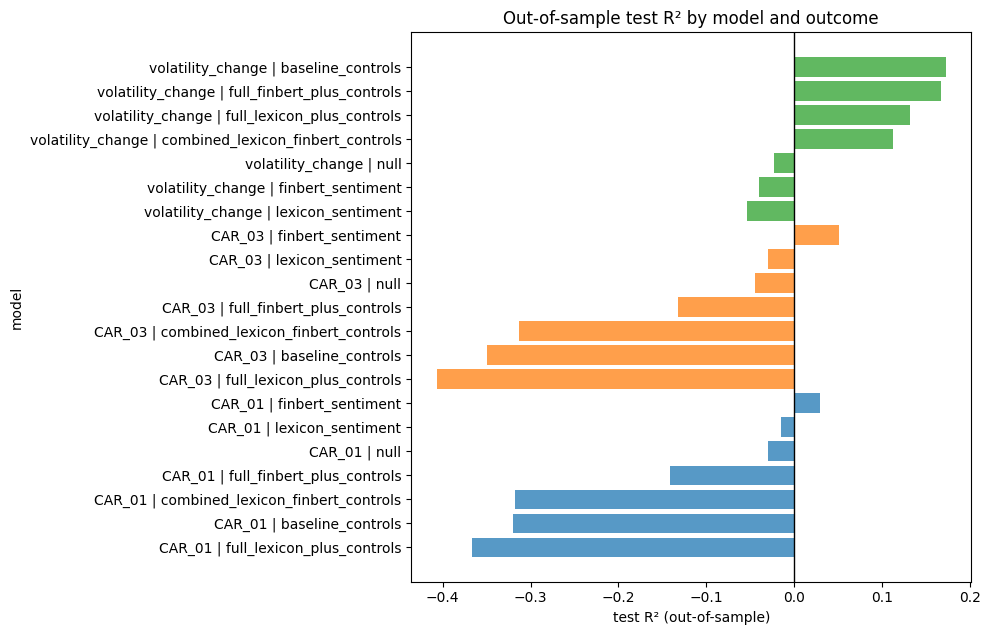

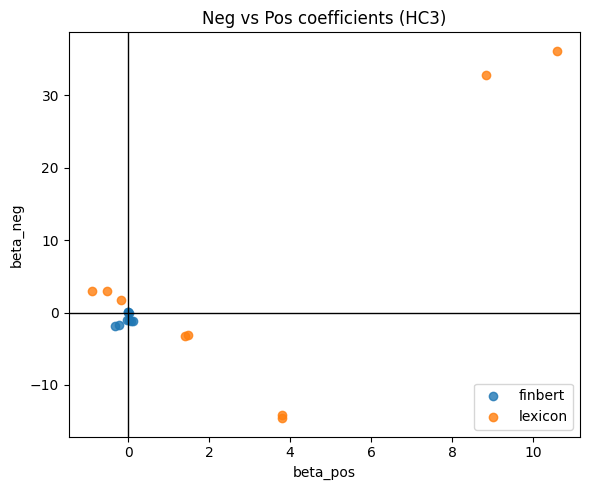

In [12]:
# Bar chart of test R^2
plot_df = performance_all.copy()
plot_df = plot_df.replace({"test_r2": {np.inf: np.nan, -np.inf: np.nan}})

fig, ax = plt.subplots(figsize=(10, 4 + 0.35 * len(plot_df["model"].unique())))

# simple grouped display: average test R^2 across outcomes per model, plus per-outcome printed table already exists
for outcome in plot_df["outcome"].unique():
    sub = plot_df[plot_df["outcome"] == outcome].copy()
    sub = sub.sort_values("test_r2")
    ax.barh([f"{outcome} | {m}" for m in sub["model"]], sub["test_r2"], alpha=0.75)

ax.axvline(0, color="black", linewidth=1)
ax.set_title("Out-of-sample test R² by model and outcome")
ax.set_xlabel("test R² (out-of-sample)")
ax.set_ylabel("model")
plt.tight_layout()
plt.show()

# Coefficient comparison scatter (neg vs pos)
if not asymmetry_results.empty:
    fig, ax = plt.subplots(figsize=(6, 5))
    for src in asymmetry_results["sentiment_source"].unique():
        sub = asymmetry_results[asymmetry_results["sentiment_source"] == src]
        ax.scatter(sub["beta_pos"], sub["beta_neg"], label=src, alpha=0.8)

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Neg vs Pos coefficients (HC3)")
    ax.set_xlabel("beta_pos")
    ax.set_ylabel("beta_neg")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Conclusion and interpretation

### What the tables and graphs mean

- **Out-of-sample test \(R^2\)** (bar chart): this measures how well a model predicts *new, unseen events* (the 2019–2020 test set) relative to a naive baseline that always predicts the test-set mean. Values:
  - **\(R^2 > 0\)**: improves on predicting the mean.
  - **\(R^2 = 0\)**: equivalent to predicting the mean.
  - **\(R^2 < 0\)**: worse than predicting the mean (often a sign of weak signal, overfitting, or unstable relationships).
- **RMSE** in the performance table: the typical size of the prediction error in the same units as the outcome (e.g., CAR units). Lower is better.
- **Neg vs Pos coefficients (HC3)** scatter: each point is a fitted model’s estimated coefficients \((\beta_{pos}, \beta_{neg})\) for one sentiment source. Points where \(\beta_{neg}\) is more negative than \(\beta_{pos}\) (i.e., below the 45-degree line if drawn) are consistent with “negative sentiment matters more than positive sentiment,” but statistical significance is determined by the formal test below.
- **Asymmetry (HC3 Wald/F) test**: for each model with a matched neg/pos pair, we test

\[
H_0: \beta_{neg} - \beta_{pos} = 0.
\]

A small p-value (e.g., \(p < 0.05\)) indicates the negative and positive coefficients are statistically different under robust (HC3) inference.

### Do sentiment features improve predictive performance?

Overall, predictive performance is **modest** for the CAR outcomes and **stronger** for volatility changes:

- **CAR outcomes (`CAR_01`, `CAR_03`)**:
  - Models using **FinBERT sentiment alone** achieve **small but positive** out-of-sample \(R^2\) (roughly 0.03–0.05 in the displayed table), while several richer specifications (especially those adding multiple controls/dummies) produce **negative** out-of-sample \(R^2\). This indicates that, in this sample, adding complexity does not reliably translate into better generalization.
  - **Lexicon sentiment** models do not show consistent out-of-sample gains over simple baselines in the displayed results.

- **Volatility change (`volatility_change`)**:
  - Out-of-sample \(R^2\) is **clearly positive** for the controls-based models (around 0.13–0.17 in the displayed table). Adding sentiment features does not consistently improve on the controls-only baseline, suggesting that **pre-event volatility and time controls** already capture most of the predictable variation in volatility change for this dataset.

### Is FinBERT better than lexicon features?

Based on the out-of-sample results shown, **FinBERT features are more informative than lexicon rates for predicting CAR**. FinBERT-only models deliver the best generalization among the sentiment-only specifications, while lexicon-only models are near-zero or negative out-of-sample.

### Main research question: is negative sentiment stronger than positive sentiment?

For **CAR outcomes**, the asymmetry tests provide **partial evidence** consistent with the hypothesis:

- In the displayed `asymmetry_results` table, the **FinBERT CAR models** (`finbert_sentiment` and `full_finbert_plus_controls`) show **statistically significant asymmetry** (\(p < 0.05\)) with \(\beta_{neg} - \beta_{pos} < 0\), leading to the interpretation **“negative stronger than positive.”**
- The same pattern appears for `CAR_03` under the **FinBERT sentiment-only** specification (\(p < 0.05\)).
- In contrast, **lexicon-based** models show **no significant asymmetry** in these results.
- For **volatility change**, asymmetry is **not statistically significant** across the shown models.

### Final conclusion (tied to the research question)

Within this dataset and modelling setup, **FinBERT-derived negative sentiment appears to be more strongly associated with short-window abnormal returns than FinBERT-derived positive sentiment**, providing *some support* for the asymmetry hypothesis in return reactions. However, the overall predictive strength for returns is **limited** (out-of-sample \(R^2\) is small and sensitive to specification), and the asymmetry finding is **not universal** across all model variants and does not extend clearly to volatility changes. Therefore, the evidence should be interpreted as **suggestive rather than definitive**, and future work should test robustness with additional finance controls and larger samples.

## Limitations

- The model set here uses only variables available in the repo (sentiment + pre-event volatility + transcript length + time dummies).
- Important finance controls that are not present (e.g., **earnings surprise**, analyst expectations, firm fundamentals) are not included; this may limit explanatory power and could bias sentiment coefficients if omitted variables correlate with sentiment.
- Sample size is modest after time-splitting; results should be interpreted cautiously and validated with robustness checks and alternative specifications.